# Homework 4

In this homework, we practice what we have learned about optimization. 

## Problem 1

Which of the following functions are convex? Argue why/why not.

1. $f(\mathbf{w}) = w_1^2 - \log(w_2) + \exp(w_3)$, where $\mathbf{w} = [w_1, w_2, w_3]^\top$;
2. $f(\mathbf{w}) = \frac{1}{2}\mathbf{w}^\top \mathbf{A}\mathbf{w} - \mathbf{b}^\top \mathbf{w}$, where $\mathbf{A} = \begin{bmatrix}1 &-1\\
-1 &1\end{bmatrix}$ and $\mathbf{b} = [-1, 1]^\top$;
3. $f(\mathbf{w}) = \frac{1}{2}\mathbf{w}^\top \mathbf{A}\mathbf{w} - \mathbf{b}^\top \mathbf{w}$, where $\mathbf{A} = \begin{bmatrix}1 &-1 &-1\\-1 &1 & -1\\ 1 & 1& -1\end{bmatrix}$ and $\mathbf{b} = [-1, 1, 1]^\top$;
4. $f(\mathbf{w}) = \|\mathbf{A}\mathbf{w} - \mathbf{b}\|_2^2$ for an arbitrary matrix $\mathbf{A} \in \mathbb{R}^{n\times d}$ and an arbitrary vector $\mathbf{b} \in \mathbb{R}^n$; 
5. $f(\mathbf{w}) = \exp(\mathbf{b}_1^\top \mathbf{w}) - \log(\mathbf{b}_2^\top \mathbf{w})$ for arbitrary vectors $\mathbf{b}_1, \mathbf{b}_2 \in \mathbb{R}^d$.

1. Let's compute the hessian of $f(\mathbf{w})$. Then $\nabla f(\mathbf{w}) = [2w_1, -\frac{1}{w_2}, e^{w_3}]^T$ and $\nabla^2 f(\mathbf{w}) = \begin{bmatrix}
   2 & 0 & 0\\
   0& \frac{1}{w_w^2} &0\\
   0 & 0 & e^{w_3}
\end{bmatrix}
$ which is PSD since the diagonal entries are positive.
2. Since $A$ is symmetric $f(\mathbf{w})$ notice $\nabla f(\mathbf{w}) = 2A\mathbf{w} + b$ so $\nabla^2 f(\mathbf{w}) = A$ whose characteristic polynomial is $\lambda^2 - 2\lambda=0$ which has all nonnegative eigenvalues so $f$ is convex. 
3. First, $\nabla f(\mathbf{w}) = (A+A^T)\mathbf{w} + b$ so $\nabla^2 f(\mathbf{w}) = \frac{A+A^T}{2}$. Since $\frac{A+A^T}{2} =
\begin{bmatrix}
1 & -1 & 0\\
-1 & 1 & 0 \\
   0 & 0 & 1
   \end{bmatrix}$ with characteristic polynomial $(-1-\lambda)\lambda(\lambda-2) = 0$ there exists a negative eigen value so $\nabla^2 f$ is not PSD. Thus $f$ is not convex.
4. Notice $f(\mathbf{w}) = ||[\sum_{i=1}^n a_{i1} w_i, \sum_{i=1}^n a_{i2}w_i \, \cdots, \sum_{i=1}^n a_{in}w_i]^T||_2^2$ which gives a degree 2 polynomial that is a nonnegative linear combination of $w_i^2, w_i$ for $i \in [1, 2, \cdots n]$. A nonnegative linear combination of convex functions is convex and since $y= w_i^2$ and $y=w_i$ are convex for arbitrary $i$ then $f$ is convex.
5. $f$ is 2x differentiable again so following a similar procedure, $\nabla f = b_1 e^{b_1^Tw}-\frac{1}{b_2^Tw}b_2$ and $\nabla^2 f = e^{b_1^Tw}b_1b_1^T + \frac{1}{b_2^Tw^2}b_2b_2^T$. For some vector $z$ we can check PSD with the definition seeing that
$$z^T\nabla^2f(w)z = e^{b_1^Tw}(b_1^Tz)^2+\frac{1}{b_2^Tw^2}(b_2^Tz)^2 \geq 0$$ so by definition $\nabla^2 f$ is PSD and $f$ is convex. 

## Problem 2

Suppose you are given a minimization problem with quadratic objective $f(\mathbf{w}) = \frac{1}{2}\|\mathbf{A}\mathbf{w} - \mathbf{b}\|_2^2,$ where $\mathbf{A} \in \mathbb{R}^{n \times d}$ and $\mathbf{b} \in \mathbb{R}^n.$ Suppose that the matrix $\mathbf{A}$ is such that the minimum eigenvalue of $\mathbf{A}^\top \mathbf{A}$ is some $\mu > 0$ and the maximum eigenvalue of  $\mathbf{A}^\top \mathbf{A}$ is some $L \geq \mu$, which implies that for any vector $\mathbf{v} \in \mathbb{R}^d,$ it holds $\mu \|\mathbf{v}\|_2^2 \leq \|\mathbf{A}\mathbf{v}\|_2^2 \leq L \|\mathbf{v}\|_2^2$ (you don't have to show this, but note that it follows from the spectral decomposition theorem, which is good to review).

1. Argue that in this case for any two vectors $\mathbf{w}, \mathbf{w'} \in \mathbb{R}^d,$ we have
$$
    f(\mathbf{w}') \geq f(\mathbf{w}) + \nabla f(\mathbf{w})^\top(\mathbf{w}' - \mathbf{w}) + \frac{\mu}{2}\|\mathbf{w}' - \mathbf{w}\|_2^2
$$
and
$$
    f(\mathbf{w}') \leq f(\mathbf{w}) + \nabla f(\mathbf{w})^\top(\mathbf{w}' - \mathbf{w}) + \frac{L}{2}\|\mathbf{w}' - \mathbf{w}\|_2^2
$$
2. Use the first part of the question to argue that in this case, assuming $\mathbf{w}_*$ is a minimizer of $f$, we have that for gradient descent with step size $\frac{1}{L}$ applied to $f$ it holds that for all $k \geq 0$, 
$$
    \|\mathbf{w}_{k+1} - \mathbf{w}_*\|_2^2 \leq \Big(1 - \frac{\mu}{L}\Big)\|\mathbf{w}_k - \mathbf{w}_*\|_2^2.
$$
3. Given $\epsilon > 0$ and assuming gradient descent was started at $\mathbf{w}_0 = \mathbf{0}_d$ (zero vector of length $d$), after how many iterations $k$ can we guarantee that $\|\mathbf{w}_k - \mathbf{w}_*\|_2\leq \epsilon$?

1. First, notice that the expansion of $$f(\mathbf{w'}) = \frac{1}{2}(\|\mathbf{Aw}-\mathbf{b}\|_2^2 + 2(\mathbf{A}^T(\mathbf{Aw}-\mathbf{b})^T(\mathbf{w'}-\mathbf{w}) + \|\mathbf{A}(\mathbf{w'}-\mathbf{w})\|_2^2$$ since $\nabla f(\mathbf{w}) = \mathbf{A}^T(\mathbf{Aw}-\mathbf{b})$. Equivalently, $$f(\mathbf{w'}) = \frac{1}{2}\|(\mathbf{Aw}-\mathbf{b})+\mathbf{A}(\mathbf{w'}-\mathbf{w})\|_2^2.$$ Since $\mu \|\mathbf{v}\|_2^2 \leq \|\mathbf{A}\mathbf{v}\|_2^2 \leq L \|\mathbf{v}\|_2^2$ for arbitrary vectors, then $\mu\|\mathbf{w'}-\mathbf{w}\|_2^2 \leq \|\mathbf{A}(\mathbf{w'}-\mathbf{w})\|_2^2$, thus $$
    f(\mathbf{w}') \geq f(\mathbf{w}) + \nabla f(\mathbf{w})^\top(\mathbf{w}' - \mathbf{w}) + \frac{\mu}{2}\|\mathbf{w}' - \mathbf{w}\|_2^2
$$
and
$$
    f(\mathbf{w}') \leq f(\mathbf{w}) + \nabla f(\mathbf{w})^T(\mathbf{w}' - \mathbf{w}) + \frac{L}{2}\|\mathbf{w}' - \mathbf{w}\|_2^2
$$ by subtitution.
2. Expanding the LHS shows $$\|\mathbf{w_{k+1}}-\mathbf{w_*}\|_2^2 = \|\mathbf{w_k}-\mathbf{w_*}\|_2^2 - \frac{2}{L}\nabla f(\mathbf{w_k})^T(\mathbf{w_k}-\mathbf{w_*})-\frac{2}{L}(f(\mathbf{w_{k+1}}-f(\mathbf{w_k}))\leq (1 - \frac{\mu}{L})\|\mathbf{w_k}-\mathbf{w_*}\|.$$ Then further simplifying shows
$$-\frac{\mu}{L}\|\mathbf{w_k}-\mathbf{w_*}\|_2^2 \geq -\frac{2}{L}\nabla f(\mathbf{w_k})^T(\mathbf{w_k}-\mathbf{w_*})-\frac{2}{L}(f(\mathbf{w_{k+1}} - f(\mathbf{w_k})$$
or after rearranging and combining like terms, 
$$f(\mathbf{w_{k+1}}) \geq f(\mathbf{w_k}) - \nabla f(\mathbf{w})^T(\mathbf{w}' - \mathbf{w}) +\frac{\mu}{2}\|\mathbf{w_k} - \mathbf{w_*}\|.$$ This statement holds as a weaker inequality than part 1, which implies validity of the original statement.
3. Using the inequality from part 2, notice that 
$$\|\mathbf{w_k} - \mathbf{w_*}\|_2^2 \leq (1-\frac{\mu}{L})^k \|\mathbf{w_0} - \mathbf{w_*}\|_2^2 = (1-\frac{\mu}{L})^k\frac{2(2f(\mathbf{w_0}) - f(\mathbf{w_*})}{\mu}$$ since the result for part 2 holds for all $k\geq 0.$ Then we know $\|\mathbf{w_k} - \mathbf{w_*}\|_2 \leq \epsilon$ when $k \geq \frac{L\log(2(f(\mathbf{w_0}-f(\mathbf{w_*}))}{\mu^2 \epsilon^2}.$ 

## Problem 3

You are given an $L$-smooth (but not necessarily convex) function $f: \mathbb{R}^d \to \mathbb{R}$ to which you wish to apply stochastic gradient descent: starting with some initial $\mathbf{w}_0 \in \mathbb{R}^d$ for all $k \geq 0$ you perform updates

$$
    \mathbf{w}_{k+1} = \mathbf{w}_k - \eta_k \mathbf{g}_k,
$$

where $\eta_k$ is the step size you get to choose and $\mathbf{g}_k$ is a stochastic estimate of the gradient $\nabla f(\mathbf{w}_k)$ for which it holds

$$
    \mathbb{E}_k[\mathbf{g}_k] = \nabla f(\mathbf{w}_k) \;\; \text{and}\;\; \mathbb{E}_k[\|\mathbf{g}_k\|_2^2] \leq G^2
$$

for some given $G < \infty.$ Here, same as in the class and lecture notes, we interpret $\mathbb{E}_k$ as the expectation conditioning on all algorithm randomness up to iteration $k$. This allows us to isolate the randomness intrinsic to the stochastic estimation in $\mathbf{g}_k$ and to ignore any randomness in $\mathbf{w}_k$ once we do the conditioning.

1. Argue that for all $k \geq 0$, there is a choice of step size $\eta_k$ (allowed to depend on $\nabla f(\mathbf{w}_k), G, L$) such that it holds

$$
        \mathbb{E}_k[f(\mathbf{w}_{k+1})] \leq f(\mathbf{w}_k) - \frac{\|\nabla f(\mathbf{w}_k)\|_2^4}{2 L G^2}.
$$

2. Given $\epsilon > 0,$ after how many iterations $k$ of this algorithm can we gurantee that $\mathbb{E}[\min_{0 \leq i \leq k}\|\nabla f(\mathbf{w}_k)\|_2] \leq \epsilon?$

1. Since $f$ is L-smooth then $$f(\mathbf{w_{k+1}}) \leq f(\mathbf{w_k}) + \mathbf{g_k}^T(-\eta_k \nabla f(\mathbf{w_k}))+\frac{L}{2}\|-\eta_k \mathbf{g_k}\|_2^2.$$ Then applying expectation to both sides where $f(\mathbf{w_k})$ is treated as constant,
$$\mathbb{E}[f(\mathbf{w_{k+1}})] \leq f(\mathbf{w_k}) - \eta_k \|\nabla f(\mathbf{w)k})\|_2^2 + \frac{\eta_k^2 L}{2} G^2.$$ Thus $
    \mathbb{E}_k[\mathbf{g}_k] = \nabla f(\mathbf{w}_k) \;\; \text{and}\;\; \mathbb{E}_k[\|\mathbf{g}_k\|_2^2] \leq G^2
$ holds when $\eta_k = \frac{\|\nabla f(\mathbf{w_k})\|_2^2}{LG^2}$.
2. Using the result from part 1, take the expectation of both sides and rearrange to show
$$\frac{\mathbb{E}[\|\nabla f(\mathbf{w_i})\|_2^4]}{2LG^2} \leq \mathbb{E}[f(\mathbf{w_i})] - \mathbb{E}[f( \mathbf{w_{i+1}})].$$
Since the pairwise sum telescopes for each vector pair $i, i+1$ then use the telescoping sum to see
$$\sum_{i=1}^k \mathbb{E}[f(\mathbf{w_i})] - \mathbb{E}[f( \mathbf{w_{i+1}})] = \mathbb{E}[f(\mathbf{w_0})] - \mathbb{E}[f( \mathbf{w_{k+1}})] \leq f(\mathbf{w_0}) - f_*$$
because $\mathbf{w_0}, \mathbf{w_*}$ are deterministic. Then with some algebra see that 
$$\mathbb{E}[\|\nabla f(\mathbf{w_i})\|_2^4] \leq \frac{2LG^2(f(\mathbf{w_0}) - f(\mathbf{w_*}))}{k+1}$$
so by Jensen's Inequality, 
$$\mathbb{E}[\|\nabla f(\mathbf{w_i})\|_2] \leq (\frac{2LG^2(f(\mathbf{w_0}) - f(\mathbf{w_*}))}{k+1})^\frac{1}{4}.$$ Thus given $\epsilon >0$, we gurantee that $\mathbb{E}[\min_{0 \leq i \leq k}\|\nabla f(\mathbf{w}_k)\|_2] \leq \epsilon$ within $k \geq \frac{2LG^2 (f(\mathbf{w_0}) - f(\mathbf{w_*}))}{\epsilon^4}$ iterations.

## Coding Assignment

In this coding assignment, you get to compare gradient descent and stochastic gradient descent (both using a constant step size) on randomly generated linear regression problems, which are quadratic problems of the form:
$$
    \min_{\mathbf{w} \in \mathbb{R}^d}f(\mathbf{w}), \;\; f(\mathbf{w}) = \frac{1}{2m}\|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2,
$$

where $\mathbf{X} \in \mathbb{R}^{m \times d}$ is the data matrix and $\mathbf{y} \in \mathbb{R}^m$ is the vector containing the corresponding labels.

You will need to import the following packages:

In [2]:
import numpy as np
import time
import matplotlib.pyplot as plt

The following function will generate random data for you:

In [3]:
def generate_data(num_samples, num_features, noise=0.1):
    X = 2 * np.random.rand(num_samples, num_features)
    w_true = np.random.randn(num_features, 1)
    bias = np.random.randn()
    y = X.dot(w_true) + bias + noise * np.random.randn(num_samples, 1)
    return X, y

1. Write Python code for a function that given an initial vector $\mathbf{w}_0,$ problem parameters $\mathbf{X}, \mathbf{y}$, a constant step size $\eta$, and number of iterations $K$, implements $K$ iterations of gradient descent applied to our linear regression problem (stated at the beginning of the coding assignment) with step size $\eta$. 

In [4]:
def f(w_t, num_samples, X, y):
    l2_norm = np.linalg.norm(X.dot(w_t) - y)
    return (l2_norm**2)/(2*num_samples)
# gradient of f 
def gf(w_t, num_samples, X, y):
    return (1/num_samples) * np.matmul(X.T, np.matmul(X, w_t) - y)

def gradient_descent(K, step_size, w_0, X, y): 
    #array to store losses
    loss = []

    w_t = w_0
    for a in range(K):
        loss.append(f(w_t, num_samples, X, y))
        w_t = w_t - step_size*gf(w_t, num_samples, X, y)
    return w_t, loss

2. Write Python code for a function that given an initial vector $\mathbf{w}_0,$ problem parameters $\mathbf{X}, \mathbf{y}$, a constant step size $\eta$, and number of iterations $K$, implements $K$ iterations of _stochastic_ gradient descent applied to our linear regression problem (stated at the beginning of the coding assignment) with step size $\eta$. The stochastic gradient estimate you should use is $\mathbf{g}_k = \mathbf{X}_i^\top(\mathbf{X}_i \mathbf{w}_k - \mathbf{y}_i),$ where $i$ is generated uniformly at random from $\{1, \dots, m\}$ and $\mathbf{X}_i$ denotes the i-th row of the data matrix $\mathbf{X}$. Argue that $\mathbb{E}_k[\mathbf{g}_k] = \nabla f(\mathbf{w}_k)$.

In [5]:
def sgd(K, step_size, w_0, X, y):
    w_t = w_0
    #array to store losses
    loss = []
    for k in range(K):
        loss.append(f(w_t, num_samples, X, y))
        #uniformly sample i in [0,500) integers
        i = np.random.randint(0,num_samples)
        #index data column and label
        X_i = X[i:i+1, :]
        y_i = y[i:i+1]
        #estimated gradient
        g_k = np.matmul(X_i.T, np.matmul(X_i, w_t)-y_i)
        w_t = w_t - step_size*g_k

    return w_t, loss

Since each vector $\mathbf{X}_i$ is picked unformly then 
$$\mathbb{E}_k[\mathbf{g}_k] = \sum_{i=1}^m \frac{1}{m}\mathbf{X}_i^T(\mathbf{X}_i\mathbf{w}_k - \mathbf{y}_i)$$
for $m$ columns of $\mathbf{X}$. Observe that because
$$\nabla f(\mathbf{w_k}) = \frac{1}{m}\mathbf{X}^T(\mathbf{X}\mathbf{w}_k - \mathbf{y}) = \mathbb{E}_k[\mathbf{g}_k]$$
then each column has probability $\frac{1}{m}$ of being picked so summing over $m$ is equivalent to performing gradient descent over the dataset.

3. Write code that sets the random seed to 0 (`np.random.seed(0)`), number of samples to 500, number of features to 100, number of iterations to 3000, and the step size (learning rate) for both algorithms to 0.005. Run both algorithms for this specification of the parameters and the random data generated using the provided code above, keeping track of the objective (loss) function value in each iteration. Measure how long each algorithm takes to run (function `time.time()` can be used to record the time in seconds at any point of your code and is useful for this). Plot the loss function over iterations comparing the two algorithms, with y-scale set to log (`plt.yscale('log')` does this). In addition, your code should print the final values of the loss function and the execution time for both algorithms. Discuss the results. 

GD Final Loss: 0.01679264306449257
SGD Final Loss: 0.02878463798884359
GD Execution Time 0.06758522987365723
SGD: Execution Time: 0.04118490219116211


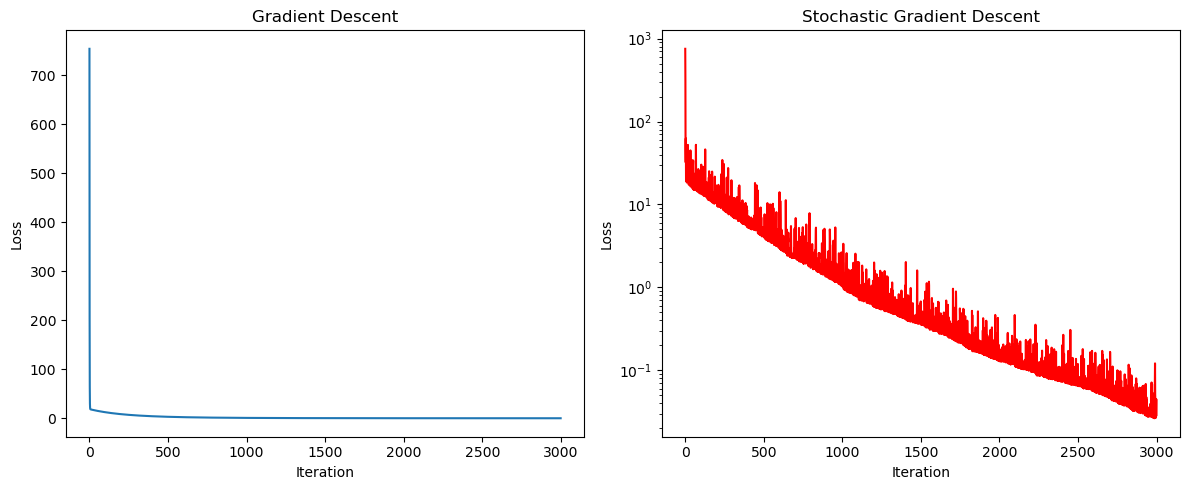

In [9]:
#setup
num_samples = 500
num_features = 100
K = 3000
step_size = 0.005
seed = np.random.seed(0)

w_0 = np.random.rand(num_features, 1)

X, y = generate_data(num_samples, num_features)
#perform gradient descent and log time
gd_start = time.time()
_, loss_gd = gradient_descent(K, step_size, w_0, X, y)
gd_time = time.time() - gd_start

#perform sgd and log time
sgd_start = time.time()
_, loss_sgd = sgd(K, step_size, w_0, X, y)
sgd_time = time.time() - sgd_start

#graph and print results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

print("GD Final Loss: " + str(loss_gd[K-1]) +"\n"+"SGD Final Loss: " + str(loss_sgd[K-1]))
print("GD Execution Time " + str(gd_time) + "\n" + "SGD: Execution Time: " + str(sgd_time))


ax1.plot(loss_gd)
plt.yscale('log')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')
ax1.set_title('Gradient Descent')

ax2.plot(loss_sgd, color='red')
plt.yscale('log')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Loss')
ax2.set_title('Stochastic Gradient Descent')

plt.tight_layout()
plt.show()